In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, root_mean_squared_error, r2_score
from sklearn.compose import make_column_selector as selector
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.impute import SimpleImputer

train_data = pd.read_csv("csv/train.csv",  encoding='latin-1')
train_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


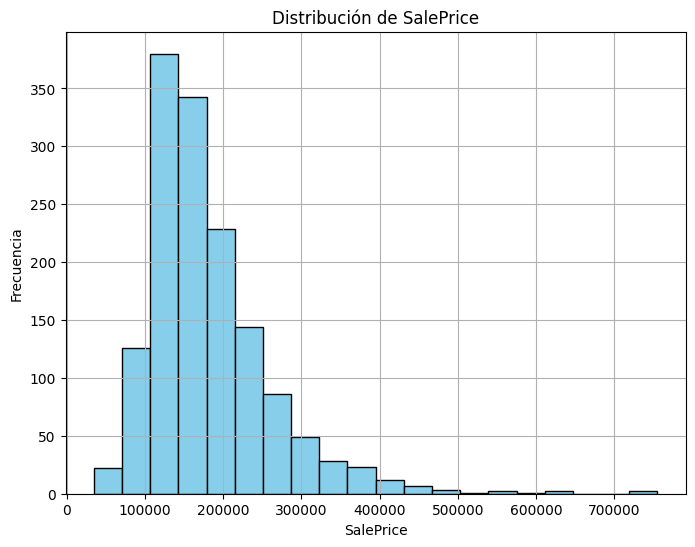

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [3]:
plt.figure(figsize=(8, 6))
plt.hist(train_data['SalePrice'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribución de SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()
print(train_data['SalePrice'].describe())

## Variable Respuesta:

La variable que se pretende predecir es el precio de vivienda (SalePrice).
Separemos en conjuntos de entrenamiento y prueba.

## Conjuntos de entrenamiento y prueba.   

Se separarán en 70% de los datos en el conjunto de entrenamiento y 30% en el conjunto de prueba, usando un muestreo aleatorio simple.   

In [4]:
train_data.pop("Id")

0          1
1          2
2          3
3          4
4          5
        ... 
1455    1456
1456    1457
1457    1458
1458    1459
1459    1460
Name: Id, Length: 1460, dtype: int64

In [5]:
threshold = 0.5 * len(train_data)  # 50% de los datos

# Eliminar columnas con demasiados NaN
train_data = train_data.dropna(axis=1, thresh=threshold)

# Crear un imputador para reemplazar NaN con la media
num_imputer = SimpleImputer(strategy="median")  # También puedes usar "mean"

# Aplicar el imputador a las columnas numéricas
numerical_columns = train_data.select_dtypes(include=['int64', 'float64']).columns
train_data[numerical_columns] = num_imputer.fit_transform(train_data[numerical_columns])

cat_imputer = SimpleImputer(strategy="most_frequent")

# Aplicar el imputador a las columnas categóricas
categorical_columns = train_data.select_dtypes(include=['object']).columns
train_data[categorical_columns] = cat_imputer.fit_transform(train_data[categorical_columns])


print(train_data.isnull().sum().to_string())


MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
Street           0
LotShape         0
LandContour      0
Utilities        0
LotConfig        0
LandSlope        0
Neighborhood     0
Condition1       0
Condition2       0
BldgType         0
HouseStyle       0
OverallQual      0
OverallCond      0
YearBuilt        0
YearRemodAdd     0
RoofStyle        0
RoofMatl         0
Exterior1st      0
Exterior2nd      0
MasVnrArea       0
ExterQual        0
ExterCond        0
Foundation       0
BsmtQual         0
BsmtCond         0
BsmtExposure     0
BsmtFinType1     0
BsmtFinSF1       0
BsmtFinType2     0
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
Heating          0
HeatingQC        0
CentralAir       0
Electrical       0
1stFlrSF         0
2ndFlrSF         0
LowQualFinSF     0
GrLivArea        0
BsmtFullBath     0
BsmtHalfBath     0
FullBath         0
HalfBath         0
BedroomAbvGr     0
KitchenAbvGr     0
KitchenQual      0
TotRmsAbvGrd     0
Functional  

In [6]:
print(train_data.dtypes)

MSSubClass       float64
MSZoning          object
LotFrontage      float64
LotArea          float64
Street            object
                  ...   
MoSold           float64
YrSold           float64
SaleType          object
SaleCondition     object
SalePrice        float64
Length: 75, dtype: object


In [7]:
y = train_data.pop("SalePrice")
X = train_data

In [8]:
X_train, X_test,y_train, y_test = train_test_split(X, y,test_size=0.3,train_size=0.7,random_state=0)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1021, 74)
(438, 74)
(1021,)
(438,)


## Separacion de variables Categoricas y numericas

In [9]:
numerical_columns_selector = selector(dtype_exclude=object)
categorical_columns_selector = selector(dtype_include=object)

numerical_columns = numerical_columns_selector(train_data)
categorical_columns = categorical_columns_selector(train_data)
print('Categoricas:\n', categorical_columns)
print('Numericas:\n',numerical_columns)

Categoricas:
 ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']
Numericas:
 ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenP

## Vamos a codificar las variables cualitativas con un onehot encoder y vamos a normalizar las variables cuantitativas

In [10]:
categorical_preprocessor = OneHotEncoder(handle_unknown="ignore")
numerical_preprocessor = StandardScaler()
preprocessor = ColumnTransformer([
    ('one-hot-encoder', categorical_preprocessor, categorical_columns),
    ('standar-scaler', numerical_preprocessor,numerical_columns)
    ])

## Modelo KNN


In [11]:
# Crear pipeline con KNN
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('knn', KNeighborsRegressor())
])

# Definir hiperparámetros a optimizar en la búsqueda
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],  # Diferentes valores de k
    'knn__weights': ['uniform', 'distance'],  # Peso de los vecinos
    'knn__p': [1, 2]  # Distancia Manhattan (p=1) vs Euclidiana (p=2)
}

# Validación cruzada con 5 folds y GridSearch
grid_search = GridSearchCV(knn_pipeline, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, error_score='raise')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, error_score='raise',
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('one-hot-encoder',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['MSZoning',
                                                                          'Street',
                                                                          'LotShape',
                                                                          'LandContour',
                                                                          'Utilities',
                                                                          'LotConfig',
                                                                          'LandSlope',
                                                                          'Neighborhood',
                                                                          'Condition1',
                                                                          'Condition2',
                                                                          'BldgType',
                                                                          'HouseStyle',
                                                                          'RoofStyle',
                                                                          'RoofMatl',
                                                                          'Exterior1...
                                                                          'BsmtHalfBath',
                                                                          'FullBath',
                                                                          'HalfBath',
                                                                          'BedroomAbvGr',
                                                                          'KitchenAbvGr',
                                                                          'TotRmsAbvGrd',
                                                                          'Fireplaces',
                                                                          'GarageYrBlt',
                                                                          'GarageCars',
                                                                          'GarageArea',
                                                                          'WoodDeckSF',
                                                                          'OpenPorchSF',
                                                                          'EnclosedPorch', ...])])),
                                       ('knn', KNeighborsRegressor())]),
             n_jobs=-1,
             param_grid={'knn__n_neighbors': [3, 5, 7, 9, 11], 'knn__p': [1, 2],
                         'knn__weights': ['uniform', 'distance']},
             scoring='neg_mean_squared_error')

## Mejor Hiperparametro

In [12]:
# Mejor modelo encontrado
best_knn = grid_search.best_estimator_
print(f"Mejor hiperparámetro: {grid_search.best_params_}")

Mejor hiperparámetro: {'knn__n_neighbors': 3, 'knn__p': 1, 'knn__weights': 'distance'}


## Metrica RMSE y R al cuadrado

In [13]:
# Evaluación en el conjunto de prueba
y_pred = best_knn.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

porcentaje = rmse / y.mean() * 100

print(f"RMSE en test: {rmse}")
print(f"R² en test: {r2}")
print(f"Porcentaje de error: {porcentaje:.2f}%")

RMSE en test: 33341.10404848946
R² en test: 0.8362600352587118
Porcentaje de error: 18.43%


# Resultados

## Dispersion entre valores reales y predicciones

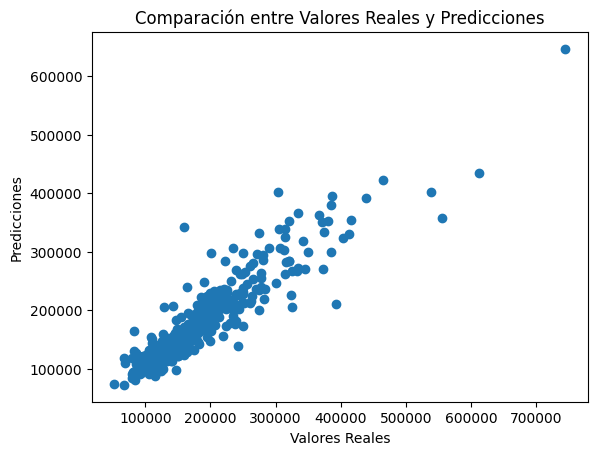

In [14]:
# Visualización de errores
plt.scatter(y_test, y_pred)
plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Comparación entre Valores Reales y Predicciones")
plt.show()

## Error del modelo

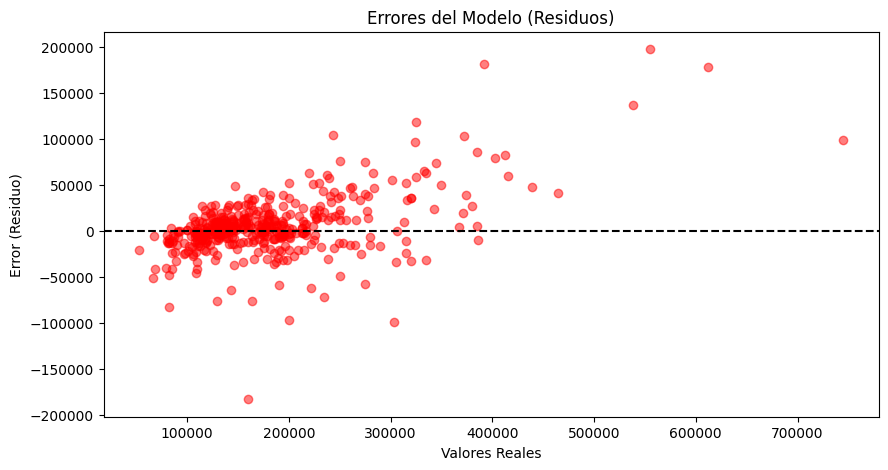

In [15]:
plt.figure(figsize=(10,5))
residuals = y_test - y_pred
plt.scatter(y_test, residuals, alpha=0.5, color='red')
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel("Valores Reales")
plt.ylabel("Error (Residuo)")
plt.title("Errores del Modelo (Residuos)")
plt.show()

## Comparacion de los valores reales y predichos

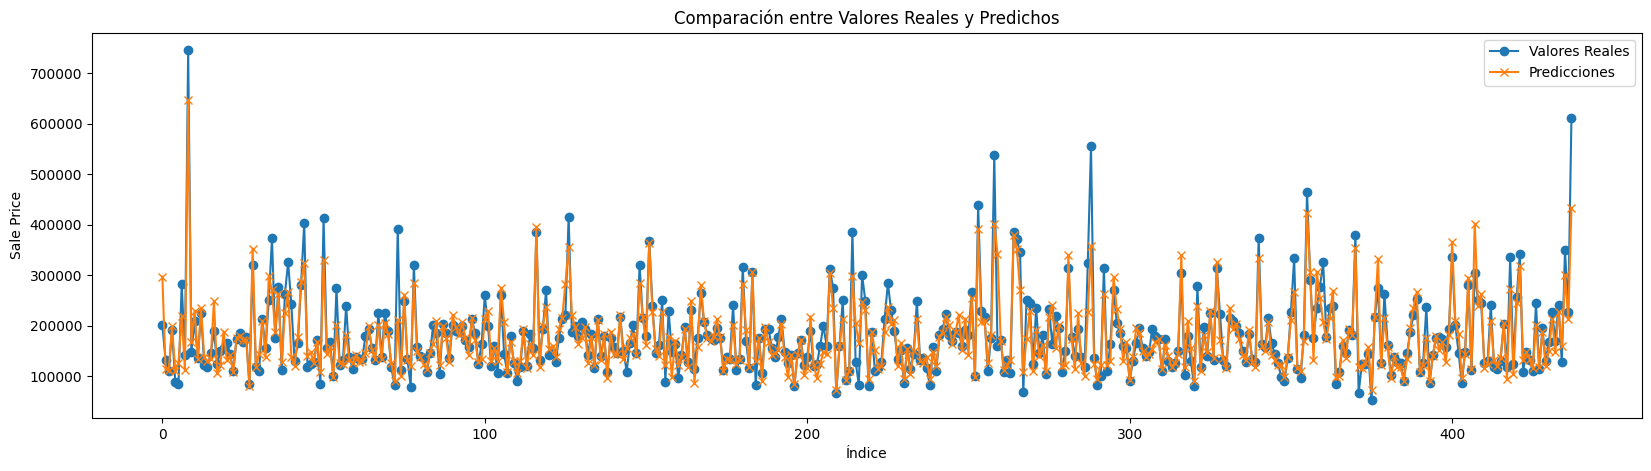

In [16]:
plt.figure(figsize=(20,5))
plt.plot(range(len(y_test)), y_test.values, label="Valores Reales", marker='o')
plt.plot(range(len(y_pred)), y_pred, label="Predicciones", marker='x')
plt.xlabel("Índice")
plt.ylabel("Sale Price")
plt.title("Comparación entre Valores Reales y Predichos")
plt.legend()
plt.show()

## Distribucion de errores

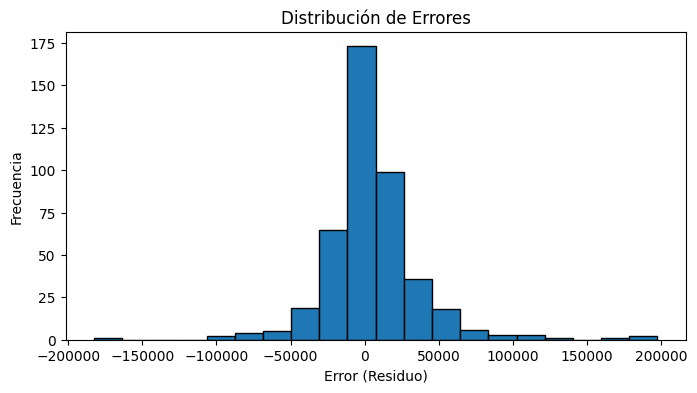

In [17]:
plt.figure(figsize=(8,4))
plt.hist(residuals, bins=20, edgecolor='black')
plt.xlabel("Error (Residuo)")
plt.ylabel("Frecuencia")
plt.title("Distribución de Errores")
plt.show()

# Ahora, se hara un modelo KNN para el valor clasificatorio PriceCategory

In [18]:
train_data_2 = pd.read_csv("csv/train.csv",  encoding='latin-1')

saleprice_summary = train_data_2["SalePrice"].describe()

# Calcular percentiles para definir los rangos de clasificación
q1 = train_data_2["SalePrice"].quantile(0.33)  # 33% más barato
q2 = train_data_2["SalePrice"].quantile(0.66)  # 66% intermedio
print(q1, q2,  train_data_2["SalePrice"].max())

# Crear la nueva variable categórica basada en los percentiles
train_data_2["PriceCategory"] = pd.cut(train_data_2["SalePrice"], 
                             bins=[train_data_2["SalePrice"].min(), q1, q2, train_data_2["SalePrice"].max()], 
                             labels=[0, 1, 2], #"Económica (0)", "Intermedia(1)", "Cara(2)" 
                             include_lowest=True)

# Mostrar resumen de la variable categórica creada
train_data_2[["PriceCategory", "SalePrice"]]

139000.0 189893.00000000006 755000


,PriceCategory,SalePrice
0,2,208500
1,1,181500
2,2,223500
3,1,140000
4,2,250000
...,...,...
1455,1,175000
1456,2,210000
1457,2,266500
1458,1,142125


In [19]:
train_data_2.pop("Id")

0          1
1          2
2          3
3          4
4          5
        ... 
1455    1456
1456    1457
1457    1458
1458    1459
1459    1460
Name: Id, Length: 1460, dtype: int64

In [20]:
threshold = 0.5 * len(train_data_2)  # 50% de los datos

# Eliminar columnas con demasiados NaN
train_data_2 = train_data_2.dropna(axis=1, thresh=threshold)

# Crear un imputador para reemplazar NaN con la media
num_imputer = SimpleImputer(strategy="median")  # También puedes usar "mean"

# Aplicar el imputador a las columnas numéricas
numerical_columns = train_data_2.select_dtypes(include=['int64', 'float64']).columns
train_data_2[numerical_columns] = num_imputer.fit_transform(train_data_2[numerical_columns])

cat_imputer = SimpleImputer(strategy="most_frequent")

# Aplicar el imputador a las columnas categóricas
categorical_columns = train_data_2.select_dtypes(include=['object']).columns
train_data_2[categorical_columns] = cat_imputer.fit_transform(train_data_2[categorical_columns])


print(train_data_2.isnull().sum().to_string())

MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
Street           0
LotShape         0
LandContour      0
Utilities        0
LotConfig        0
LandSlope        0
Neighborhood     0
Condition1       0
Condition2       0
BldgType         0
HouseStyle       0
OverallQual      0
OverallCond      0
YearBuilt        0
YearRemodAdd     0
RoofStyle        0
RoofMatl         0
Exterior1st      0
Exterior2nd      0
MasVnrArea       0
ExterQual        0
ExterCond        0
Foundation       0
BsmtQual         0
BsmtCond         0
BsmtExposure     0
BsmtFinType1     0
BsmtFinSF1       0
BsmtFinType2     0
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
Heating          0
HeatingQC        0
CentralAir       0
Electrical       0
1stFlrSF         0
2ndFlrSF         0
LowQualFinSF     0
GrLivArea        0
BsmtFullBath     0
BsmtHalfBath     0
FullBath         0
HalfBath         0
BedroomAbvGr     0
KitchenAbvGr     0
KitchenQual      0
TotRmsAbvGrd     0
Functional  

In [21]:
y = train_data_2.pop("PriceCategory")
X = train_data_2

In [22]:
X_train, X_test,y_train, y_test = train_test_split(X, y,test_size=0.3,train_size=0.7,random_state=0)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1021, 75)
(438, 75)
(1021,)
(438,)


## Separacion de variables Categoricas y numericas

In [23]:
numerical_columns_selector = selector(dtype_exclude=object)
categorical_columns_selector = selector(dtype_include=object)

numerical_columns = numerical_columns_selector(train_data_2)
categorical_columns = categorical_columns_selector(train_data_2)
print('Categoricas:\n', categorical_columns)
print('Numericas:\n',numerical_columns)

Categoricas:
 ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']
Numericas:
 ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenP

In [24]:
categorical_preprocessor = OneHotEncoder(handle_unknown="ignore")
numerical_preprocessor = StandardScaler()
preprocessor = ColumnTransformer([
    ('one-hot-encoder', categorical_preprocessor, categorical_columns),
    ('standar-scaler', numerical_preprocessor,numerical_columns)
    ])

# Aplicar la transformación a los datos de entrenamiento y prueba
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)


## Verificar cual es la mejor cantidad de vecinos

In [25]:
# Probar diferentes valores de K
accuracies = []
cv_scores = []
k_values = range(1, 41)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, p=3, metric='euclidean')
    knn.fit(X_train_transformed, y_train)
    scores = cross_val_score(knn, X_train_transformed, y_train, cv=5, scoring='accuracy')
    cv_scores.append(np.mean(scores))
    y_pred = knn.predict(X_test_transformed)
    accuracies.append(accuracy_score(y_test, y_pred))

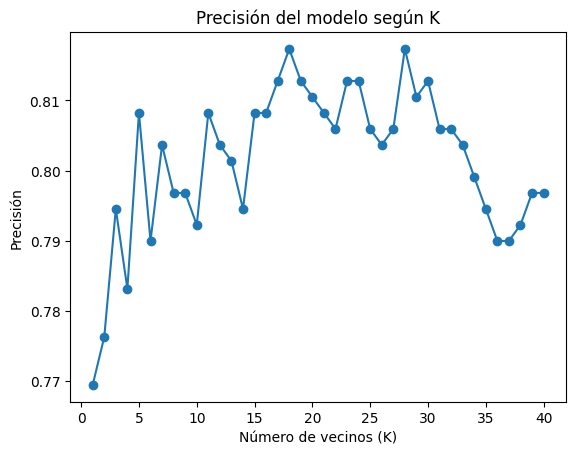

In [26]:
# Graficar la precisión vs. K
plt.plot(k_values, accuracies, marker='o')
plt.xlabel('Número de vecinos (K)')
plt.ylabel('Precisión')
plt.title('Precisión del modelo según K')
plt.show()

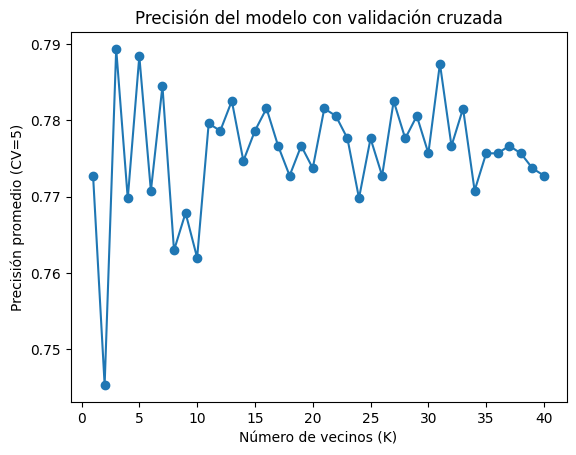

Mejor valor de K según CV=5: 3


In [27]:
# Graficamos los resultados
plt.plot(k_values, cv_scores, marker='o')
plt.xlabel('Número de vecinos (K)')
plt.ylabel('Precisión promedio (CV=5)')
plt.title('Precisión del modelo con validación cruzada')
plt.show()

# Mejor K basado en la validación cruzada
best_k = k_values[np.argmax(cv_scores)]
print(f"Mejor valor de K según CV=5: {best_k}")

In [28]:
# Comparemos K's
import math
print(math.sqrt(len(y_test)))

20.92844953645635


## Realizar el modelo

In [29]:
# Definir el modelo con K=3
knn = KNeighborsClassifier(n_neighbors=3, p=3, metric='euclidean')
knn.fit(X_train_transformed, y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=3, p=3)

# Resultados

In [30]:
# Predicción en el conjunto de prueba
y_pred = knn.predict(X_test_transformed)

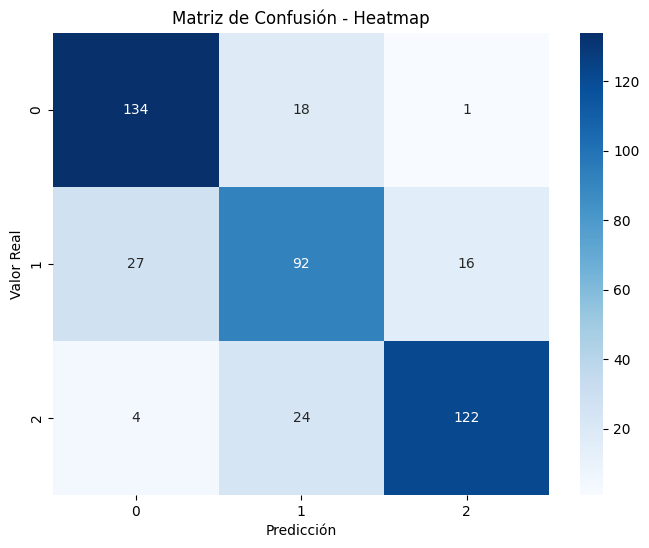


Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       153
           1       0.69      0.68      0.68       135
           2       0.88      0.81      0.84       150

    accuracy                           0.79       438
   macro avg       0.79      0.79      0.79       438
weighted avg       0.80      0.79      0.79       438

Precisión del modelo: 0.79


In [31]:
# Matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=set(y_test), yticklabels=set(y_test))
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión - Heatmap')
plt.show()

# Reporte de clasificación
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

# Precisión del modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión del modelo: {accuracy:.2f}")

# Hay Overfitting?

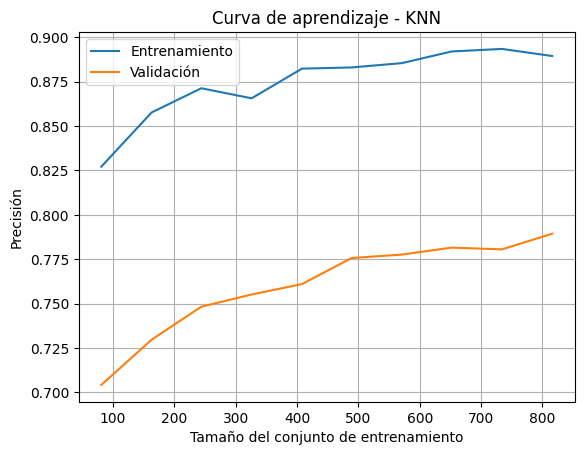

Precisión promedio cross-validation: 0.79 (+/- 0.03)


In [33]:
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    knn, X_train_transformed, y_train, cv=5, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.plot(train_sizes, train_mean, label='Entrenamiento')
plt.plot(train_sizes, test_mean, label='Validación')
plt.xlabel('Tamaño del conjunto de entrenamiento')
plt.ylabel('Precisión')
plt.title('Curva de aprendizaje - KNN')
plt.legend()
plt.grid()
plt.show()

cv_scores = cross_val_score(knn, X_train_transformed, y_train, cv=5, scoring='accuracy')
print(f'Precisión promedio cross-validation: {cv_scores.mean():.2f} (+/- {cv_scores.std():.2f})')


# Modelo validacion cruzada

In [35]:
# Modelo KNN
knn_cv = KNeighborsClassifier(n_neighbors=3, p=3, metric='euclidean')

# Validación cruzada (k-fold con 5 particiones)
cv_scores = cross_val_score(knn_cv, X_train_transformed, y_train, cv=5, scoring='accuracy')

# Resultados
print("Precisión por fold:", cv_scores)
print(f"Precisión promedio cross-validation: {cv_scores.mean():.2f} (+/- {cv_scores.std():.2f})")

knn.fit(X_train_transformed, y_train)
y_pred = knn.predict(X_test_transformed)

accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión del modelo anterior (test set): {accuracy:.2f}")


Precisión por fold: [0.82926829 0.80882353 0.7745098  0.79411765 0.74019608]
Precisión promedio cross-validation: 0.79 (+/- 0.03)
Precisión del modelo anterior (test set): 0.79


# Hiperametros para KNN

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2]
}

grid_search = GridSearchCV(estimator=knn_pipeline, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)


NameError: name 'pipe_knn' is not defined